In [2]:
from pathlib import Path
from typing import Iterable, Optional
import numpy as np
import matplotlib.pyplot as plt
import RCP_analysis as rcp

SOURCE = "NPRW"                  # "UA" or "NPRW"
CORR_WIN_MS = (125.0, 225.0)     # ABSOLUTE window in peri-stim time (ms), rel_t=0 at stim onset
PERI_WIN_MS = (-800.0, 600.0)    # just for sanity, not used directly here
Z_SCORE_FEATURES = True          # z-score channels across trials before distances
SAVE_SVG = True                  # save under figures/rsa_from_peristim/
MIN_TRIALS_PER_COND = 4          # drop conditions (NPZ files) with fewer trials
MIN_VALID_FEATURES = 2           # trial must have at least this many finite channel features
FILE_SLICE = slice(None)         # e.g., slice(None, 10) to cap number of NPZs

REPO_ROOT = Path().resolve().parents[2]
PARAMS = rcp.load_experiment_params(
    REPO_ROOT / "config" / "params.yaml",
    repo_root=REPO_ROOT,
)
SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE  = SESSION_LOC / "results"; OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
FIG_DIR = OUT_BASE / "figures" / "rsa_from_peristim"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_DIRS = [
    PERI_ROOT / "stim_reaches" / "target_A",
    PERI_ROOT / "stim_reaches" / "target_B",
]
keep_baseline_port = "A"

def _plot_rdm_with_block_ticks(
    SIM: np.ndarray,
    block_sizes: list[int],
    block_labels: list[str],
    title: str,
    out_svg: Path | None,
    ax: plt.Axes | None = None,
    vmin: float = -1.0,
    vmax: float = 1.0,
):
    """
    Plot *similarity* matrix (correlation r in [-1, 1]) with:
      - small ticks BETWEEN conditions at block boundaries (no labels)
      - text labels centered on each block (no ticks at the centers),
        mirrored on two axes.

    If ax is None, creates its own figure and handles saving/showing.
    If ax is provided, draws into that axes and leaves saving/showing to caller.
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 10))
    else:
        fig = ax.figure

    im = ax.imshow(
        SIM,
        aspect="equal",
        origin="upper",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)

    cum = np.cumsum(block_sizes)
    starts = np.r_[0, cum[:-1]]
    boundaries = cum[:-1] - 0.5
    centers = starts + (np.asarray(block_sizes) / 2.0) - 0.5

    # minor ticks at boundaries
    ax.set_xticks(boundaries, minor=True)
    ax.set_yticks(boundaries, minor=True)
    ax.tick_params(axis="x", which="minor", length=4, width=0.8, direction="out")
    ax.tick_params(axis="y", which="minor", length=4, width=0.8, direction="out")

    # no major ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # text labels at centers
    for c, lab in zip(centers, block_labels):
        ax.text(
            c, -0.02, lab,
            transform=ax.get_xaxis_transform(),
            ha="center", va="top",
            fontsize=8, rotation=90,
            clip_on=False,
        )
        ax.text(
            -0.02, c, lab,
            transform=ax.get_yaxis_transform(),
            ha="right", va="center",
            fontsize=8,
            clip_on=False,
        )

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Correlation (r)")

    if own_fig:
        fig.tight_layout()
        if out_svg is not None:
            fig.savefig(out_svg, dpi=300)
            print(f"[rsa] wrote {out_svg}")
        plt.show()
        plt.close(fig)


def _trial_features_from_peristim_npz(
    npz_path: Path,
    source: str = "NPRW",
    corr_win_ms: tuple[float, float] = CORR_WIN_MS,
    use_kinematics: bool = False,
    channels=None,
) -> tuple[np.ndarray, list[str], dict]:
    """
    Build per-trial feature vectors from a peri-stim NPZ.

    Neural mode (use_kinematics=False):
      - NPRW_rates_zeroed / UA_rates_zeroed : (n_trials, n_channels, T)
      - NPRW_rel_t / UA_rel_t              : (T,)

    Kinematics mode (use_kinematics=True):
      - beh_cam0_segs (and optionally beh_cam1_segs) : (n_rows, n_trials, T, ...)
      - beh_cam0_names : (n_rows,)
        Rows whose name is 'start', 'ta', or 'tb' are dropped.
      - Uses NPRW_rel_t / UA_rel_t for the time axis; CORR_WIN_MS applies to time.
      - Cam0 and Cam1 features are concatenated per trial.
    """
    peristim_npz = np.load(npz_path, allow_pickle=True)

    # ---- choose time axis ----
    if use_kinematics:
        t_key = "beh_rel_t"
        rate_key = None  # not used in kinematics mode
    else:
        src = source.upper()
        if src == "NPRW":
            t_key = "NPRW_rel_t"
            rate_key = "NPRW_rates_zeroed"
        else:
            t_key = "UA_rel_t"
            rate_key = "UA_rates_zeroed"

    if t_key not in peristim_npz.files:
        return np.zeros((0, 0), float), [], {"cond": None, "n_trials": 0, "n_ch": 0}
    rel_t = peristim_npz[t_key].astype(float)  # (T,)

    # ---------- basic metadata ----------
    br_idx = None
    if "br_idx" in peristim_npz.files:
        try:
            br_idx = int(peristim_npz["br_idx"])
        except Exception:
            br_idx = None

    target = npz_path.parent.name  # "Target_A" / "Target_B"
    is_baseline = "control_reaches" in str(npz_path)
    cond_label = "Baseline" if is_baseline else br_idx

    # ---- time window mask ----
    w0 = float(corr_win_ms[0])
    w1 = float(corr_win_ms[1])
    mask_t = (rel_t >= w0) & (rel_t <= w1)
    if not np.any(mask_t):
        print(f"[rsa][warn] window {corr_win_ms} ms has no samples; skipping file {npz_path.name}")
        return np.zeros((0, 0), float), [], {
            "cond": cond_label,
            "n_trials": 0,
            "n_ch": 0,
        }

    # Neural
    if not use_kinematics:
        if rate_key not in peristim_npz.files:
            return np.zeros((0, 0), float), [], {
                "cond": cond_label,
                "n_trials": 0,
                "n_ch": 0,
            }

        rates = peristim_npz[rate_key].astype(float)  # (n_trials, n_channels, T)
        

        if rates.size == 0 or rates.shape[-1] != rel_t.size:
            return np.zeros((0, 0), float), [], {
                "cond": cond_label,
                "n_trials": 0,
                "n_ch": rates.shape[1] if rates.ndim >= 2 else 0,
            }

        n_trials, n_ch, _ = rates.shape
        # ---- optional channel subset (neural only) ----
        if channels is not None:
            if isinstance(channels, slice):
                ch_idx = np.arange(n_ch)[channels]
            else:
                ch_idx = np.asarray(channels)
                if ch_idx.dtype == bool:
                    if ch_idx.size != n_ch:
                        raise ValueError(f"channels bool mask len={ch_idx.size} != n_ch={n_ch}")
                    ch_idx = np.flatnonzero(ch_idx)
            rates = rates[:, ch_idx, :]
            n_trials, n_ch, _ = rates.shape

        # average over time in window → (n_trials, n_channels)
        X = np.nanmean(rates[:, :, mask_t], axis=2)

    # Kinematics
    else:
        if "beh_cam0_segs" not in peristim_npz.files:
            print(f"[rsa][warn] {npz_path.name}: beh_cam0_segs missing; skipping.")
            return np.zeros((0, 0), float), [], {
                "cond": cond_label,
                "n_trials": 0,
                "n_ch": 0,
            }

        cam0 = peristim_npz["beh_cam0_segs"].astype(float)   # (rows0, trials, T, ...)
        cam0_names = np.asarray(peristim_npz.get("beh_cam0_names", []), dtype=object).astype(str)

        # Drop rows named 'start', 'ta', 'tb'
        if cam0_names.size and cam0_names.shape[0] == cam0.shape[0]:
            bad = np.isin(cam0_names, ["start", "ta", "tb"])
            keep_rows0 = ~bad
            cam0 = cam0[keep_rows0, ...]
        else:
            keep_rows0 = np.ones(cam0.shape[0], dtype=bool)

        # Time dimension check
        if cam0.shape[2] != rel_t.size:
            print(f"[rsa][warn] {npz_path.name}: cam0 T={cam0.shape[2]} != len(rel_t)={rel_t.size}; skipping.")
            return np.zeros((0, 0), float), [], {
                "cond": cond_label,
                "n_trials": 0,
                "n_ch": 0,
            }

        # Apply time mask on axis=2
        cam0 = cam0[:, :, mask_t, ...]   # (rows0_kept, trials, T_sel, ...)

        # Move trials to front and flatten remaining dims → (trials, F0)
        cam0_tr = np.moveaxis(cam0, 1, 0)        # (trials, rows0_kept, T_sel, ...)
        n_trials = cam0_tr.shape[0]
        feat0 = cam0_tr.reshape(n_trials, -1)    # (trials, F0)

        feats = [feat0]

        # Optional cam1
        if "beh_cam1_segs" in peristim_npz.files:
            cam1 = peristim_npz["beh_cam1_segs"].astype(float)
            # require same #trials and time dimension
            if cam1.shape[2] == rel_t.size and cam1.shape[1] == n_trials:
                cam1 = cam1[:, :, mask_t, ...]
                cam1_tr = np.moveaxis(cam1, 1, 0)   # (trials, rows1, T_sel, ...)
                feat1 = cam1_tr.reshape(n_trials, -1)
                feats.append(feat1)
            else:
                print(f"[rsa][warn] {npz_path.name}: cam1 shape/time mismatch; ignoring cam1.")

        X = np.concatenate(feats, axis=1)    # (trials, total_features)
        n_ch = X.shape[1]

    # ---- drop trials with too few finite features ----
    valid_trials = np.isfinite(X).sum(axis=1) >= MIN_VALID_FEATURES
    if not valid_trials.any():
        return np.zeros((0, 0), float), [], {
            "cond": cond_label,
            "n_trials": 0,
            "n_ch": X.shape[1] if X.ndim == 2 else 0,
        }
    X = X[valid_trials, :]

    n_final = X.shape[0]
    labels = [
        f"{'Baseline' if is_baseline else f'cond{br_idx}'}_{target}_t{j+1}"
        for j in range(n_final)
    ]

    info = {
        "cond": cond_label,
        "target": target,
        "is_baseline": bool(is_baseline),
        "n_trials": n_final,
        "n_ch": X.shape[1],
        "file": npz_path.name,
    }
    return X, labels, info

def _baseline_port_from_name(fname: str, ctrl_br_file: dict = {"A": 2, "B": 22}) -> str | None:
    for port, br in ctrl_br_file.items():
        if f"BR_{br:03d}" in fname:
            return port
    return None

def run_trial_rsa_from_peristim(
    source: str = SOURCE,
    corr_win_ms: tuple[float, float] = CORR_WIN_MS,
    cond_label_extras: dict | None = None,
    use_kinematics: bool | None = None,
    vmin: float = -1.0,
    vmax: float = 1.0,
    skip_conds: Optional[Iterable[int]] = None,
    baseline_port: Optional[str] = "A",
    channels=None,
    cond_order: Optional[Iterable] = None,
    average_within_condition: bool = False,
):
    """
    source:
      - "NPRW"  -> neural, NPRW rates
      - "UA"    -> neural, UA rates
      - "Kinematics" (or anything starting with "kin") -> kinematics mode
    average_within_condition:
      - If True, average all trials within each condition to produce one vector 
        per condition before computing the RSM. This reduces the matrix from 
        N_trials x N_trials to N_conditions x N_conditions.

    """
    cond_label_extras = cond_label_extras or {}
    skip_conds = set(skip_conds or [])

    # If caller didn’t explicitly set use_kinematics, infer from source
    if use_kinematics is None:
        use_kinematics = source.lower().startswith("kin")

    # For titles / filenames
    if use_kinematics:
        mode_str = "kinematics"
        neural_source = "NPRW"   # unused for data, just for logging
        probe_str = "behavior"
    else:
        mode_str = "neural"
        neural_source = source
        # crude probe label from source; refine later if you store per-probe info
        src_upper = neural_source.upper()
        if src_upper == "NPRW":
            probe_str = "NPRW"
        elif src_upper == "UA":
            probe_str = "UA"
        else:
            probe_str = src_upper

    print(
        f"[rsa] running RSA for {neural_source!r}, "
        f"window={corr_win_ms[0]}–{corr_win_ms[1]} ms"
    )

    # collect NPZ paths from both Target_* dirs
    npz_files = []
    for td in TARGET_DIRS:
        if not td.exists():
            continue
        npz_files.extend(sorted(td.glob("*.npz")))
    npz_files = npz_files[FILE_SLICE]

    if not npz_files:
        raise SystemExit(f"[rsa] no PeriStim NPZs found in {TARGET_DIRS}")

    all_X, all_labels = [], []
    block_sizes = []
    block_targets = []   # "Target_A" / "Target_B"
    block_conds = []     # BR_File index or "Baseline"
    
    skipped = {
        "baseline_wrong_port": [],     # list[str] of filenames
        "in_skip_conds": set(),        # set[int]
        "too_few_trials": set(),       # set[int]
        "missing_or_empty": [],        # list[str] (optional)
    }

    
    for path in npz_files:
        X, labels, info = _trial_features_from_peristim_npz(
            path,
            source=neural_source,
            corr_win_ms=corr_win_ms,
            use_kinematics=use_kinematics,
            channels=channels,
        )

        cond = info.get("cond", None)
        is_baseline = info.get("is_baseline", False)
        target = info.get("target", path.parent.name)  # "Target_A"/"Target_B"
        
        if is_baseline:
            port = _baseline_port_from_name(path.name)
            if port != keep_baseline_port:
                skipped["baseline_wrong_port"].append(path.name)
                continue

        # optional: skip specific stim conditions by BR_File index
        if (not is_baseline) and (cond is not None) and (cond in skip_conds):
            skipped["in_skip_conds"].add(int(cond))
            continue

        n_trials = int(info.get("n_trials", 0))
        if (n_trials < MIN_TRIALS_PER_COND) and (not is_baseline):
            # cond can be None for weird files; guard
            if cond is not None:
                skipped["too_few_trials"].add(int(cond))
            else:
                skipped["missing_or_empty"].append(path.name)
            continue

        all_X.append(X)
        all_labels.extend(labels)
        block_sizes.append(n_trials)
        block_targets.append(target)
        block_conds.append(cond)

    # ---- one-line skip summary ----
    parts = []
    if skipped["in_skip_conds"]:
        parts.append("skip_conds=" + ",".join(map(str, sorted(skipped["in_skip_conds"]))))

    if skipped["too_few_trials"]:
        parts.append(
            f"too_few_trials(<{MIN_TRIALS_PER_COND})="
            + ",".join(map(str, sorted(skipped["too_few_trials"])))
        )

    if skipped["baseline_wrong_port"]:
        parts.append(
            f"baseline_wrong_port(!={keep_baseline_port})="
            + str(len(skipped["baseline_wrong_port"]))
        )

    if skipped["missing_or_empty"]:
        parts.append("other_skips=" + str(len(skipped["missing_or_empty"])))

    if parts:
        print("[rsa][skip-summary] " + " | ".join(parts))

    if not all_X:
        raise SystemExit("[rsa] no conditions with enough trials")

    # ---- optional: reorder conditions ----
    if cond_order is not None:
        cond_order = list(cond_order)

        def _cond_key(cond):
            # Normalize baseline label
            return "Baseline" if cond == "Baseline" or cond is None else cond

        # Build ordering index
        order_map = {c: i for i, c in enumerate(cond_order)}

        def sort_key(i):
            c = _cond_key(block_conds[i])
            return (order_map.get(c, len(order_map)), i)

        perm = sorted(range(len(block_conds)), key=sort_key)

        # Apply permutation consistently
        all_X = [all_X[i] for i in perm]
        block_sizes   = [block_sizes[i] for i in perm]
        block_targets = [block_targets[i] for i in perm]
        block_conds   = [block_conds[i] for i in perm]

    # Ensure all feature matrices have the same number of columns
    feature_dims = [X.shape[1] for X in all_X]
    if len(set(feature_dims)) > 1:
        min_dim = min(feature_dims)
        print(
            "[rsa][warn] feature dimension mismatch across NPZs: "
            f"{feature_dims} -> cropping all to {min_dim}"
        )
        all_X = [X[:, :min_dim] for X in all_X]

    X_all = np.vstack(all_X)  # (N_total_trials, n_features)

    # optional z-score across trials per feature
    if Z_SCORE_FEATURES and X_all.size:
        with np.errstate(invalid="ignore", divide="ignore"):
            mu = np.nanmean(X_all, axis=0, keepdims=True)
            sd = np.nanstd(X_all, axis=0, keepdims=True)
            X_all = (X_all - mu) / np.where(sd > 0, sd, 1.0)

    # final safety: drop any remaining NaN trials
    valid_rows = np.isfinite(X_all).all(axis=1)
    if not valid_rows.all():
        n_drop = int((~valid_rows).sum())
        print(f"[rsa][note] dropping {n_drop} trials post-normalization")
        X_all = X_all[valid_rows, :]
        all_labels = [lbl for lbl, keep in zip(all_labels, valid_rows) if keep]

        # re-estimate block sizes to keep ticks honest
        new_block_sizes = []
        cursor = 0
        for sz in block_sizes:
            idx = np.arange(cursor, cursor + sz)
            kept = np.intersect1d(idx, np.where(valid_rows)[0], assume_unique=False)
            new_block_sizes.append(int(kept.size))
            cursor += sz

        # drop completely empty blocks while keeping targets/conds aligned
        blk = [
            (s, targ, cond)
            for s, targ, cond in zip(new_block_sizes, block_targets, block_conds)
            if s > 0
        ]
        if not blk:
            raise SystemExit("[rsa] all blocks empty after final filtering")
        block_sizes, block_targets, block_conds = map(list, zip(*blk))

    # ---- optional: average trials within each condition ----
    if average_within_condition:
        print("[rsa] averaging trials within each condition")
        X_cond_means = []
        cursor = 0
        for sz in block_sizes:
            X_cond_means.append(np.nanmean(X_all[cursor:cursor + sz, :], axis=0))
            cursor += sz
        X_all = np.vstack(X_cond_means)  # (n_conditions, n_features)
        block_sizes = [1] * len(block_sizes)  # each block is now just 1 "trial"

    # correlation similarity across *all* trials
    SIM_all = np.corrcoef(X_all)

    # figure out block start indices (in the concatenated trial order)
    block_starts = []
    offset = 0
    for sz in block_sizes:
        block_starts.append(offset)
        offset += sz

    # group blocks by target
    targets_present = sorted(set(block_targets))
    targets_present = [t for t in ("Target_A", "Target_B") if t in targets_present] or targets_present

    # build one figure with up to 2 subplots (Target_A, Target_B)
    n_panels = len(targets_present)
    fig, axes = plt.subplots(
        1, n_panels,
        figsize=(8 * n_panels, 8),
        squeeze=False
    )
    axes = axes[0]
    
    for ax, target in zip(axes, targets_present):
        # collect blocks belonging to this target
        block_indices = [i for i, t in enumerate(block_targets) if t == target]
        if not block_indices:
            ax.set_visible(False)
            continue

        # per-target block sizes & cond IDs
        sizes_t = [block_sizes[i] for i in block_indices]
        conds_t = [block_conds[i] for i in block_indices]

        # per-target trial indices in the concatenated matrix
        idxs_t = []
        for i in block_indices:
            start = block_starts[i]
            sz = block_sizes[i]
            idxs_t.extend(range(start, start + sz))
        idxs_t = np.array(idxs_t, dtype=int)

        # subset similarity matrix for this target
        SIM_t = SIM_all[np.ix_(idxs_t, idxs_t)]

        # build block labels for this target, using cond_label_extras
        block_labels_t = []
        for cond in conds_t:
            if cond == "Baseline" or cond is None:
                base = cond_label_extras.get("Baseline", "Baseline")
            else:
                base = cond_label_extras.get(cond, f"Cond {cond}")
            block_labels_t.append(f"{base}")

        target_disp = {
            "Target_A": "Left reaches",
            "Target_B": "Right reaches",
        }.get(target, target.replace("_", " "))
        
        title = (
            f"{target_disp} ({mode_str}, {probe_str})  "
            f"{int(corr_win_ms[0])} to {int(corr_win_ms[1])} ms  "
            f"n={len(idxs_t)}, {len(sizes_t)} conditions"
        )

        out_svg_t = (
            FIG_DIR / f"RSA_from_peristim_{mode_str}_{target}_"
                    f"win{int(corr_win_ms[0])}-{int(corr_win_ms[1])}.svg"
            if SAVE_SVG else None
        )
        # and for the combined figure:
        out_svg_all = FIG_DIR / (
            f"RSA_from_peristim_{mode_str}_Targets_AB_"
            f"win{int(corr_win_ms[0])}-{int(corr_win_ms[1])}.svg"
        )

        _plot_rdm_with_block_ticks(
            SIM_t,
            sizes_t,
            block_labels_t,
            title,
            out_svg=out_svg_t,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
        )
        
    fig.tight_layout()
    if SAVE_SVG:
        out_svg_all = FIG_DIR / (
            f"RSA_from_peristim_{source}_{mode_str}_Targets_AB_"
            f"win{int(corr_win_ms[0])}-{int(corr_win_ms[1])}.svg"
        )
        fig.savefig(out_svg_all, dpi=300)
        print(f"[rsa] wrote combined figure {out_svg_all}")
    plt.show()

    print(f"[rsa] final: total trials={X_all.shape[0]}  channels={X_all.shape[1]}")


In [3]:
cond_label_extras = {
    "Baseline": "Control reaches",
    11: "1 pulse",
    12: "2 pulses",
    14: "4 pulses",
    15: "8 pulses",
    16: "20 pulses",
    17: "40 pulses",
}
# # Kinematics-based RSA, same window
# run_trial_rsa_from_peristim("Kinematics", corr_win_ms=(-200.0, 200.0),
#                             cond_label_extras=cond_label_extras
#                             )

[rsa] running RSA for 'NPRW', window=-600.0–-5.0 ms
[rsa][skip-summary] skip_conds=23,24,25,27 | too_few_trials(<4)=20,29,30
[rsa] wrote combined figure /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_from_peristim_NPRW_neural_Targets_AB_win-600--5.svg


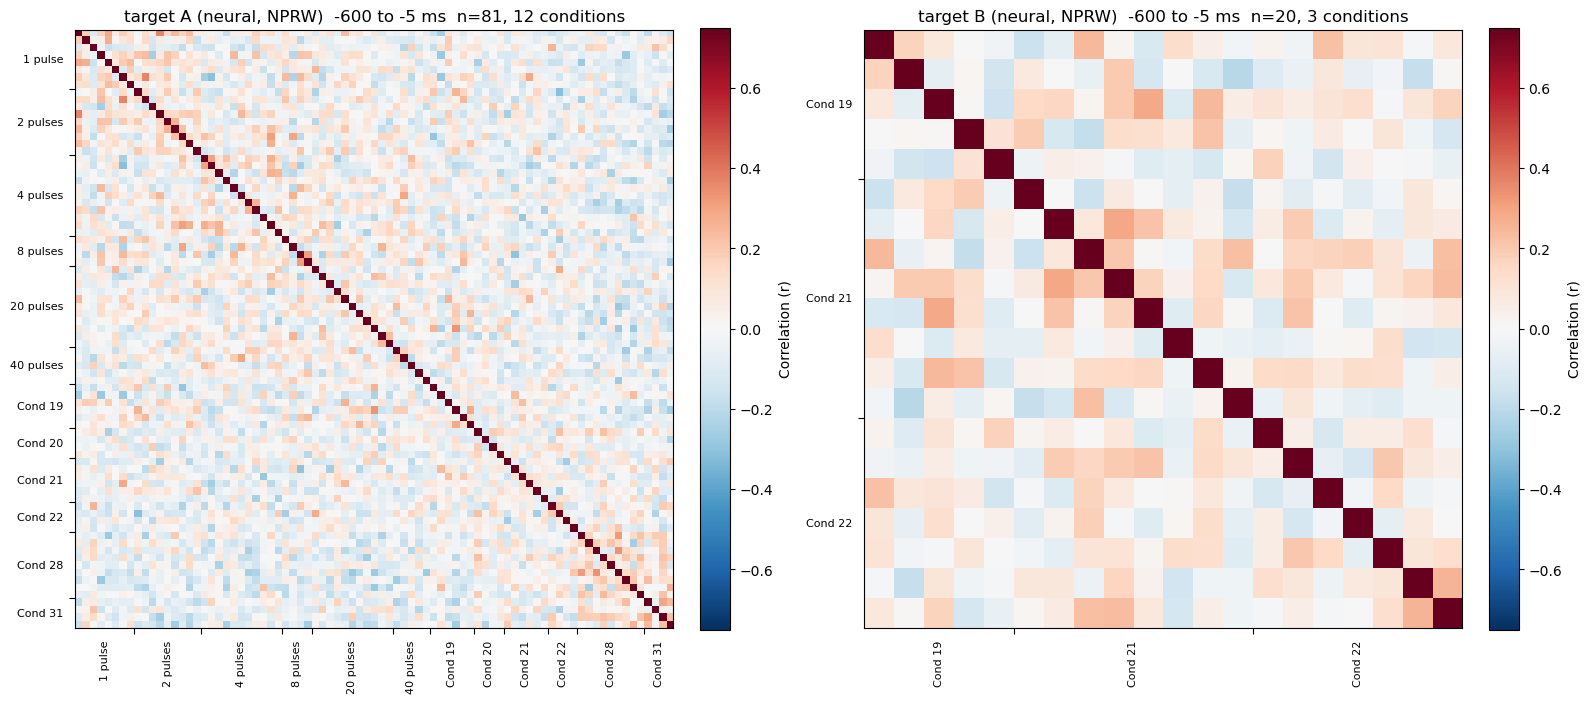

[rsa] final: total trials=101  channels=128


In [5]:
%matplotlib inline
# run_trial_rsa_from_peristim(source="NPRW", 
#                             corr_win_ms=(-600.0, -5.0),
#                             cond_label_extras=cond_label_extras,
#                             vmin=-0.75, vmax=0.75,
#                             baseline_port='A',
#                             skip_conds = {2, 3, 8, 9, 23, 24, 25, 27},
#                             cond_order=["Baseline", 10, 5, 6, 11, 7],
#                             )

run_trial_rsa_from_peristim(source="NPRW", 
                            corr_win_ms=(-600.0, -5.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            baseline_port='A',
                            skip_conds = {2, 3, 6, 8, 9, 23, 24, 25, 27},
                            cond_order=["Baseline", 10, 5, 11, 7],
                            )

In [7]:
%matplotlib inline
_CTRL_BR_FILE = {"A": 2, "B": 22}

CHANNEL_CRITERION   = "union"        # "movement" | "stim" | "union" | None

MOVE_BASE_WIN_MS    = (-800.0, -500.0)
MOVE_RESP_WIN_MS    = (0.0,  300.0)
STIM_WIN_MS         = (105.0,  150.0)
N_STD_THRESH_MVT        = 0.7
N_STD_THRESH_STIM        = 2

def _rk(source: str) -> tuple[str, str]:
    if source.upper() == "NPRW":
        return "NPRW_rates_zeroed", "NPRW_rel_t"
    return "UA_rates_zeroed", "UA_rel_t"


def _load_rt(path: Path, source: str):
    """Return (rates [n_trials, n_ch, T], rel_t [T]) or (None, None)."""
    rate_key, t_key = _rk(source)
    npz = np.load(path, allow_pickle=True)
    if t_key not in npz.files or rate_key not in npz.files:
        return None, None
    rates = npz[rate_key].astype(float)
    rel_t = npz[t_key].astype(float)
    if rates.size == 0 or rates.shape[-1] != rel_t.size:
        return None, None
    return rates, rel_t


def _tmask(rel_t: np.ndarray, win: tuple[float, float]) -> np.ndarray:
    return (rel_t >= win[0]) & (rel_t <= win[1])


def compute_movement_mask(
    baseline_paths: list[Path],
    source: str,
    base_win: tuple[float, float] = MOVE_BASE_WIN_MS,
    resp_win: tuple[float, float] = MOVE_RESP_WIN_MS,
    n_std: float = N_STD_THRESH_MVT,
) -> np.ndarray | None:
    n_ch = None
    ever_passes = None

    for path in baseline_paths:
        rates, rel_t = _load_rt(path, source)
        if rates is None:
            continue
        mb = _tmask(rel_t, base_win)
        mr = _tmask(rel_t, resp_win)
        if not mb.any() or not mr.any():
            continue

        n_ch_file = rates.shape[1]
        if n_ch is None:
            n_ch = n_ch_file
            ever_passes = np.zeros(n_ch, dtype=bool)
        if n_ch_file != n_ch:
            print(f"[chan-sel][move] ch mismatch in {path.name}; skipping")
            continue

        r_base = rates[:, :, mb]                 # (n_trials, n_ch, T_base)
        r_resp = rates[:, :, mr]                 # (n_trials, n_ch, T_resp)

        r_flat = r_base.transpose(1, 0, 2).reshape(r_base.shape[1], -1)  # (n_ch, n_trials*T_base)
        mu     = np.nanmean(r_flat, axis=1)      # (n_ch,)
        std    = np.nanstd(r_flat,  axis=1)      # (n_ch,)
        thresh = mu + n_std * std

        r_resp_median = np.nanmedian(r_resp, axis=0)                       # (n_ch, T_resp)
        passes = np.any(np.abs(r_resp_median - mu[:, None]) > n_std * std[:, None], axis=1)
        passes = np.asarray(passes, dtype=bool)
        ever_passes |= passes
        
        # try to get region names from the NPZ for the title
        try:
            _npz = np.load(path, allow_pickle=True)
            region_names = _npz["ua_region_names"] if "ua_region_names" in _npz.files else None
            region_arr   = _npz["ua_region"]       if "ua_region"       in _npz.files else None
        except Exception:
            region_names = region_arr = None

        r_all        = rates.transpose(1, 0, 2)          # (n_ch, n_trials, T)
        median_trace = np.nanmedian(r_all, axis=1)        # (n_ch, T)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
        vext = np.nanpercentile(np.abs(median_trace), 95)

        for ax, (label, ch_mask) in zip(axes, [
            ("all",     np.ones(n_ch, dtype=bool)),
            ("failing", ~passes),
            ("passing", passes),
        ]):
            if not ch_mask.any():
                ax.set_visible(False)
                continue
            traces = median_trace[ch_mask]
            im = ax.imshow(traces, aspect="auto", origin="upper",
                        extent=[rel_t[0], rel_t[-1], traces.shape[0], 0],
                        vmin=-vext, vmax=vext, cmap="RdBu_r")
            ax.axvline(base_win[0], color="red", linewidth=1, linestyle="--")
            ax.axvline(base_win[1], color="red", linewidth=1, linestyle="--")
            ax.axvline(resp_win[0], color="blue",  linewidth=1, linestyle="--")
            ax.axvline(resp_win[1], color="blue",  linewidth=1, linestyle="--")
            ax.axvline(0, color="k", linewidth=1)
            ax.set_title(f"{label} ({ch_mask.sum()} ch)")
            
            # add region boundary lines
            if region_arr is not None:
                ch_subset = np.where(ch_mask)[0]
                subset_regions = region_arr[ch_subset]
                for i in range(1, len(ch_subset)):
                    if subset_regions[i] != subset_regions[i-1]:
                        ax.axhline(i - 0.5, color="black", linewidth=0.8, linestyle="-")
            if region_arr is not None and region_names is not None:
                ch_subset = np.where(ch_mask)[0]
                subset_regions = region_arr[ch_subset]
                ytick_pos, ytick_labels = [], []
                for rid in np.unique(subset_regions):
                    rows = np.where(subset_regions == rid)[0]
                    ytick_pos.append(rows.mean())
                    ytick_labels.append(str(region_names[rid]))
                ax.set_yticks(ytick_pos)
                ax.set_yticklabels(ytick_labels, fontsize=7)
            else:
                ax.set_ylabel("channel")
            plt.colorbar(im, ax=ax, label="firing rate (baselined)")

        axes[-1].set_xlabel("time (ms)")
        br_tag = next((p for p in path.stem.split("__") if "BR_" in p), path.stem)
        plt.suptitle(f"Movement mask  n_std={n_std}  {br_tag}", fontsize=10)
        plt.tight_layout()
        plt.show()

    if ever_passes is None:
        print("[chan-sel][move] no usable baseline files")
        return None
    print(f"[chan-sel][move] {ever_passes.sum()}/{n_ch} channels pass movement criterion")
    return ever_passes


def _build_ctrl_pool(
    baseline_paths: list[Path],
    source: str,
    stim_win: tuple[float, float] = STIM_WIN_MS,
) -> np.ndarray | None:
    chunks = []
    for path in baseline_paths:
        rates, rel_t = _load_rt(path, source)
        if rates is None:
            continue
        m = _tmask(rel_t, stim_win)
        if not m.any():
            continue
        r = rates[:, :, m]                              # (n_trials, n_ch, T_win)
        chunks.append(r.transpose(1, 0, 2).reshape(r.shape[1], -1))
    if not chunks:
        return None
    pool = np.concatenate(chunks, axis=1)               # (n_ch, N)
    print(f"[chan-sel][stim] ctrl pool: {pool.shape[1]} time×trial samples")
    return pool


def compute_stim_mask(
    stim_path: Path,
    ctrl_pool: np.ndarray,
    source: str,
    stim_win: tuple[float, float] = STIM_WIN_MS,
    n_std: float = N_STD_THRESH_STIM,
    baseline_rates: np.ndarray | None = None,
    baseline_rel_t: np.ndarray | None = None,
) -> np.ndarray | None:
    br_tag   = next((p for p in stim_path.stem.split("__") if "BR_" in p), stim_path.stem)
    plot_title = f"Stim mask  n_std={n_std}  {br_tag}"

    rates, rel_t = _load_rt(stim_path, source)
    try:
        _npz = np.load(stim_path, allow_pickle=True)
        region_names = _npz["ua_region_names"] if "ua_region_names" in _npz.files else None
        region_arr   = _npz["ua_region"]       if "ua_region"       in _npz.files else None
    except Exception:
        region_names = region_arr = None
            
    if rates is None:
        return None
    m = _tmask(rel_t, stim_win)
    if not m.any():
        return None
    n_ch = rates.shape[1]
    if ctrl_pool.shape[0] != n_ch:
        print(f"[chan-sel][stim] ch mismatch for {stim_path.name}; skipping stim mask")
        return None

    ctrl_thresh = n_std * np.nanstd(ctrl_pool, axis=1)
    ctrl_mu     = np.nanmean(ctrl_pool, axis=1)
    stim_mean   = np.nanmean(rates[:, :, m], axis=2)    # (n_trials, n_ch)
    passes      = np.any(np.abs(stim_mean - ctrl_mu[None, :]) > ctrl_thresh[None, :], axis=0)
    print(f"[chan-sel][stim] {passes.sum()}/{n_ch} pass for {stim_path.name}")

    if not hasattr(compute_stim_mask, "_debug_targets"):
        compute_stim_mask._debug_targets = set()

    tgt_tag = next((p for p in stim_path.parts if "target_" in p), "unknown")

    if tgt_tag not in compute_stim_mask._debug_targets:
        compute_stim_mask._debug_targets.add(tgt_tag)

        rates_stim  = rates
        median_stim = np.nanmedian(rates_stim.transpose(1, 0, 2), axis=1)  # (n_ch, T)

        fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=False)
        stim_vals = np.abs(median_stim)
        if baseline_rates is not None:
            bl_median_full = np.nanmedian(baseline_rates.transpose(1, 0, 2), axis=1)
            base_vals = np.abs(bl_median_full)
            vext = np.nanpercentile(np.concatenate([stim_vals.ravel(), base_vals.ravel()]), 95)
        else:
            vext = np.nanpercentile(stim_vals, 95)
            
        for ax, (label, ch_mask) in zip(axes, [
            ("baseline (all channels)",  np.ones(n_ch, dtype=bool)),
            ("stim (all channels)",      np.ones(n_ch, dtype=bool)),
            ("failing",                  ~np.asarray(passes, dtype=bool)),
            ("passing",                  np.asarray(passes, dtype=bool)),
        ]):
            if not ch_mask.any():
                ax.set_visible(False)
                continue

            if label == "baseline (all channels)":
                if baseline_rates is not None:
                    bl_median = np.nanmedian(baseline_rates.transpose(1, 0, 2), axis=1)  # (n_ch, T)
                    im = ax.imshow(bl_median, aspect="auto", origin="upper",
                                   extent=[baseline_rel_t[0], baseline_rel_t[-1], bl_median.shape[0], 0],
                                   vmin=-vext, vmax=vext, cmap="RdBu_r")
                    ax.axvline(stim_win[0], color="blue", linewidth=1, linestyle="--")
                    ax.axvline(stim_win[1], color="blue", linewidth=1, linestyle="--")
                    ax.axvline(0, color="k", linewidth=1)
                    ax.axvspan(0, 105, color="gray", alpha=0.5)
                    ax.set_title(f"baseline (all) ({n_ch} ch)")
                    ax.set_xlabel("time (ms)")
                    if region_arr is not None:
                        ch_subset = np.where(ch_mask)[0]
                        subset_regions = region_arr[ch_subset]
                        for i in range(1, len(ch_subset)):
                            if subset_regions[i] != subset_regions[i-1]:
                                ax.axhline(i - 0.5, color="black", linewidth=0.8, linestyle="-")
                    if region_arr is not None and region_names is not None:
                        ch_subset = np.where(ch_mask)[0]
                        subset_regions = region_arr[ch_subset]
                        ytick_pos, ytick_labels = [], []
                        for rid in np.unique(subset_regions):
                            rows = np.where(subset_regions == rid)[0]
                            ytick_pos.append(rows.mean())
                            ytick_labels.append(str(region_names[rid]))
                        ax.set_yticks(ytick_pos)
                        ax.set_yticklabels(ytick_labels, fontsize=7)
                    else:
                        ax.set_ylabel("channel")
                    plt.colorbar(im, ax=ax, label="firing rate (baselined)")
            else:
                traces = median_stim[ch_mask]
                im = ax.imshow(traces, aspect="auto", origin="upper",
                               extent=[rel_t[0], rel_t[-1], traces.shape[0], 0],
                               vmin=-vext, vmax=vext, cmap="RdBu_r")
                ax.axvline(stim_win[0], color="green",  linewidth=1, linestyle="--")
                ax.axvline(stim_win[1], color="green",  linewidth=1, linestyle="--")
                ax.axvline(0, color="k", linewidth=1)
                ax.axvspan(0, 105, color="gray", alpha=1)
                ax.set_title(f"{label} ({ch_mask.sum()} ch)")
                ax.set_xlabel("time (ms)")

                # region boundaries and labels
                if region_arr is not None:
                    ch_subset = np.where(ch_mask)[0]
                    subset_regions = region_arr[ch_subset]
                    for i in range(1, len(ch_subset)):
                        if subset_regions[i] != subset_regions[i-1]:
                            ax.axhline(i - 0.5, color="black", linewidth=0.8, linestyle="-")
                if region_arr is not None and region_names is not None:
                    ch_subset = np.where(ch_mask)[0]
                    subset_regions = region_arr[ch_subset]
                    ytick_pos, ytick_labels = [], []
                    for rid in np.unique(subset_regions):
                        rows = np.where(subset_regions == rid)[0]
                        ytick_pos.append(rows.mean())
                        ytick_labels.append(str(region_names[rid]))
                    ax.set_yticks(ytick_pos)
                    ax.set_yticklabels(ytick_labels, fontsize=7)
                else:
                    ax.set_ylabel("channel")
                plt.colorbar(im, ax=ax, label="firing rate (baselined)")
                
        plt.suptitle(plot_title, fontsize=10)
        plt.tight_layout()
        fig.savefig(f"debug_stim_mask_{stim_path.stem}.png", dpi=150, bbox_inches="tight")
        plt.show()

    return passes


def _build_rsm_pairwise(blocks: list[dict]) -> tuple[np.ndarray, list[int]]:
    sizes   = [b["X_z"].shape[0] for b in blocks]
    offsets = np.r_[0, np.cumsum(sizes)]
    N       = int(offsets[-1])
    SIM     = np.full((N, N), np.nan)

    n_blocks = len(blocks)
    for bi in range(n_blocks):
        for bj in range(bi, n_blocks):
            pair_mask = blocks[bi]["base_mask"] | blocks[bj]["base_mask"]
            if not pair_mask.any():
                pair_mask = np.ones(blocks[bi]["X_z"].shape[1], bool)

            ri = np.arange(offsets[bi], offsets[bi + 1])
            rj = np.arange(offsets[bj], offsets[bj + 1])
            ni, nj = len(ri), len(rj)

            Xi = blocks[bi]["X_z"][:, pair_mask]
            Xj = blocks[bj]["X_z"][:, pair_mask]

            X_cat = Xi if bi == bj else np.vstack([Xi, Xj])

            valid = np.isfinite(X_cat).all(axis=1)
            if valid.sum() < 2:
                continue
            X_cat[~valid] = 0.0

            C = np.corrcoef(X_cat)

            if bi == bj:
                SIM[np.ix_(ri, ri)] = C
                if not valid.all():
                    SIM[np.ix_(ri[~valid], ri)] = np.nan
                    SIM[np.ix_(ri, ri[~valid])] = np.nan
            else:
                SIM[np.ix_(ri, ri)] = C[:ni, :ni]
                SIM[np.ix_(rj, rj)] = C[ni:, ni:]
                SIM[np.ix_(ri, rj)] = C[:ni, ni:]
                SIM[np.ix_(rj, ri)] = C[ni:, :ni]

    return SIM, sizes


def run_trial_rsa_channel_criterion(
    source: str = SOURCE,
    corr_win_ms: tuple[float, float] = CORR_WIN_MS,
    channel_criterion: str | None = CHANNEL_CRITERION,
    cond_label_extras: dict | None = None,
    vmin: float = -1.0,
    vmax: float = 1.0,
    skip_conds: Optional[Iterable[int]] = None,
    baseline_port: Optional[str] = "A",
    cond_order: Optional[Iterable] = None,
):
    cond_label_extras = cond_label_extras or {}
    skip_conds        = set(skip_conds or [])
    criterion         = (channel_criterion or "").lower()

    print(f"[rsa-ch] source={source!r}  criterion={channel_criterion!r}  win={corr_win_ms}")

    if hasattr(compute_stim_mask, "_debug_targets"):
        del compute_stim_mask._debug_targets

    npz_files = []
    for td in TARGET_DIRS:
        if td.exists():
            npz_files.extend(sorted(td.glob("*.npz")))
    npz_files = npz_files[FILE_SLICE]
    if not npz_files:
        raise SystemExit(f"[rsa-ch] no NPZs in {TARGET_DIRS}")

    blocks_raw = []
    skipped = {"skip_conds": set(), "too_few": set(), "other": []}

    baseline_dirs = [
        PERI_ROOT / "control_reaches" / "target_A",
        PERI_ROOT / "control_reaches" / "target_B",
    ]
    baseline_candidates = []
    for bd in baseline_dirs:
        if bd.exists():
            baseline_candidates.extend(sorted(bd.glob("*.npz")))

    ctrl_br     = _CTRL_BR_FILE.get((baseline_port or "A").upper())
    ctrl_br_tag = f"BR_{ctrl_br:03d}"
    baseline_paths = []
    for bd in baseline_dirs:
        matches = sorted([p for p in baseline_candidates if ctrl_br_tag in p.stem and bd in p.parents])
        if matches:
            baseline_paths.append(matches[0])
    
    if not baseline_paths:
        baseline_paths = baseline_candidates[:1]
        print(f"[rsa-ch][warn] no file matching {ctrl_br_tag} in control_reaches; using {baseline_paths[0].name if baseline_paths else 'none'}")
    else:
        print(f"[rsa-ch] baseline: {[p.name for p in baseline_paths]}")

    for path in baseline_paths:
        X, labels, info = _trial_features_from_peristim_npz(
            path, source=source, corr_win_ms=corr_win_ms, channels=None
        )
        n_trials = int(info.get("n_trials", 0))
        if n_trials == 0:
            continue
        blocks_raw.append({
            "X":           X,
            "cond":        "Baseline",
            "target":      path.parent.name,
            "is_baseline": True,
            "stim_mask":   None,
            "path":        path,
        })

    move_mask = None
    ctrl_pool = None

    if criterion in ("movement", "union"):
        move_mask = compute_movement_mask(baseline_paths, source)

    if criterion in ("stim", "union"):
        ctrl_pool = _build_ctrl_pool(baseline_paths, source)
        if ctrl_pool is None:
            print("[rsa-ch][warn] no ctrl pool for stim criterion; stim mask disabled")

    for path in npz_files:
        X, labels, info = _trial_features_from_peristim_npz(
            path, source=source, corr_win_ms=corr_win_ms, channels=None
        )
        cond     = info.get("cond", None)
        target   = info.get("target", path.parent.name)
        n_trials = int(info.get("n_trials", 0))

        if cond in skip_conds:
            if cond is not None:
                skipped["skip_conds"].add(int(cond))
            continue
        if n_trials < MIN_TRIALS_PER_COND:
            if cond is not None:
                skipped["too_few"].add(int(cond))
            else:
                skipped["other"].append(path.name)
            continue
        if n_trials == 0:
            skipped["other"].append(path.name)
            continue

        stim_mask = None
        if criterion in ("stim", "union") and ctrl_pool is not None:
            bl_rates, bl_rel_t = _load_rt(baseline_paths[0], source)
            stim_mask = compute_stim_mask(
                path, ctrl_pool, source,
                baseline_rates=bl_rates,
                baseline_rel_t=bl_rel_t,
            )

        blocks_raw.append({
            "X":           X,
            "cond":        cond,
            "target":      target,
            "is_baseline": False,
            "stim_mask":   stim_mask,
            "path":        path,
        })

    parts = []
    if skipped["skip_conds"]:
        parts.append("skip_conds=" + ",".join(map(str, sorted(skipped["skip_conds"]))))
    if skipped["too_few"]:
        parts.append(f"too_few(<{MIN_TRIALS_PER_COND})=" + ",".join(map(str, sorted(skipped["too_few"]))))
    if skipped["other"]:
        parts.append(f"other={len(skipped['other'])}")
    if parts:
        print("[rsa-ch][skip] " + " | ".join(parts))

    if not blocks_raw:
        raise SystemExit("[rsa-ch] no usable blocks")

    # debug: print all blocks being used
    for b in blocks_raw:
        print(f"  {'BASELINE' if b['is_baseline'] else 'STIM    '} | target={b['target']} | cond={b['cond']} | n_trials={b['X'].shape[0]} | path={b['path'].name}")

    if cond_order is not None:
        order_map = {c: i for i, c in enumerate(cond_order)}
        def _okey(b):
            c = "Baseline" if b["is_baseline"] else b["cond"]
            return order_map.get(c, len(order_map))
        blocks_raw = sorted(blocks_raw, key=_okey)

    dims = [b["X"].shape[1] for b in blocks_raw]
    if len(set(dims)) > 1:
        min_dim = min(dims)
        print(f"[rsa-ch][warn] n_ch mismatch {set(dims)} → cropping to {min_dim}")
        for b in blocks_raw:
            b["X"] = b["X"][:, :min_dim]
            if b["stim_mask"] is not None:
                b["stim_mask"] = b["stim_mask"][:min_dim]
        if move_mask is not None:
            move_mask = move_mask[:min_dim]

    X_all = np.vstack([b["X"] for b in blocks_raw])
    if Z_SCORE_FEATURES and X_all.size:
        with np.errstate(invalid="ignore", divide="ignore"):
            mu = np.nanmean(X_all, axis=0, keepdims=True)
            sd = np.nanstd( X_all, axis=0, keepdims=True)
            X_all_z = (X_all - mu) / np.where(sd > 0, sd, 1.0)
    else:
        X_all_z = X_all.copy()

    cursor = 0
    for b in blocks_raw:
        n = b["X"].shape[0]
        b["X_z"] = X_all_z[cursor:cursor + n, :]
        cursor += n

    def _base_mask(b: dict) -> np.ndarray:
        n = b["X_z"].shape[1]
        all_ch = np.ones(n, bool)
        if criterion == "movement":
            return move_mask if move_mask is not None else all_ch
        if criterion == "stim":
            sm = b["stim_mask"]
            return sm if (not b["is_baseline"]) and sm is not None else all_ch
        if criterion == "union":
            mm = move_mask if move_mask is not None else all_ch
            sm = b["stim_mask"]
            return (mm | sm) if (not b["is_baseline"]) and sm is not None else mm
        if criterion == "intersection":
            mm = move_mask if move_mask is not None else all_ch
            sm = b["stim_mask"]
            return (mm & sm) if (not b["is_baseline"]) and sm is not None else mm
        return all_ch

    for b in blocks_raw:
        b["base_mask"] = _base_mask(b)

    targets_present = [t for t in ("target_A", "target_B")
                       if any(b["target"] == t for b in blocks_raw)]
    if not targets_present:
        targets_present = sorted({b["target"] for b in blocks_raw})

    n_panels = len(targets_present)
    fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 8), squeeze=False)
    axes = axes[0]

    for ax, target in zip(axes, targets_present):
        tblocks = [b for b in blocks_raw if b["target"] == target]
        if not tblocks:
            ax.set_visible(False)
            continue

        SIM, sizes_t = _build_rsm_pairwise(tblocks)
        n_total = SIM.shape[0]

        block_labels_t = [
            cond_label_extras.get("Baseline", "Baseline") if b["is_baseline"]
            else cond_label_extras.get(b["cond"], f"Cond {b['cond']}")
            for b in tblocks
        ]

        target_disp = {"target_A": "Left reaches", "target_B": "Right reaches"}.get(
            target, target.replace("_", " ")
        )
        crit_str = channel_criterion or "all-ch"
        title = (
            f"{target_disp} ({source.upper()}, ch={crit_str})  "
            f"{int(corr_win_ms[0])} to {int(corr_win_ms[1])} ms  "
            f"n={n_total} trials, {len(tblocks)} conds"
        )

        _plot_rdm_with_block_ticks(
            SIM, sizes_t, block_labels_t, title,
            out_svg=None, ax=ax, vmin=vmin, vmax=vmax,
        )

    fig.tight_layout()
    if SAVE_SVG:
        crit_tag = (channel_criterion or "allch").replace(" ", "")
        out_svg = FIG_DIR / (
            f"RSA_criterion-{crit_tag}_{source}_"
            f"win{int(corr_win_ms[0])}-{int(corr_win_ms[1])}.svg"
        )
        fig.savefig(out_svg, dpi=300)
        print(f"[rsa-ch] wrote {out_svg}")
    plt.show()
    print(f"[rsa-ch] done: {sum(b['X'].shape[0] for b in blocks_raw)} total trials")


[rsa-ch] source='NPRW'  criterion='movement'  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz


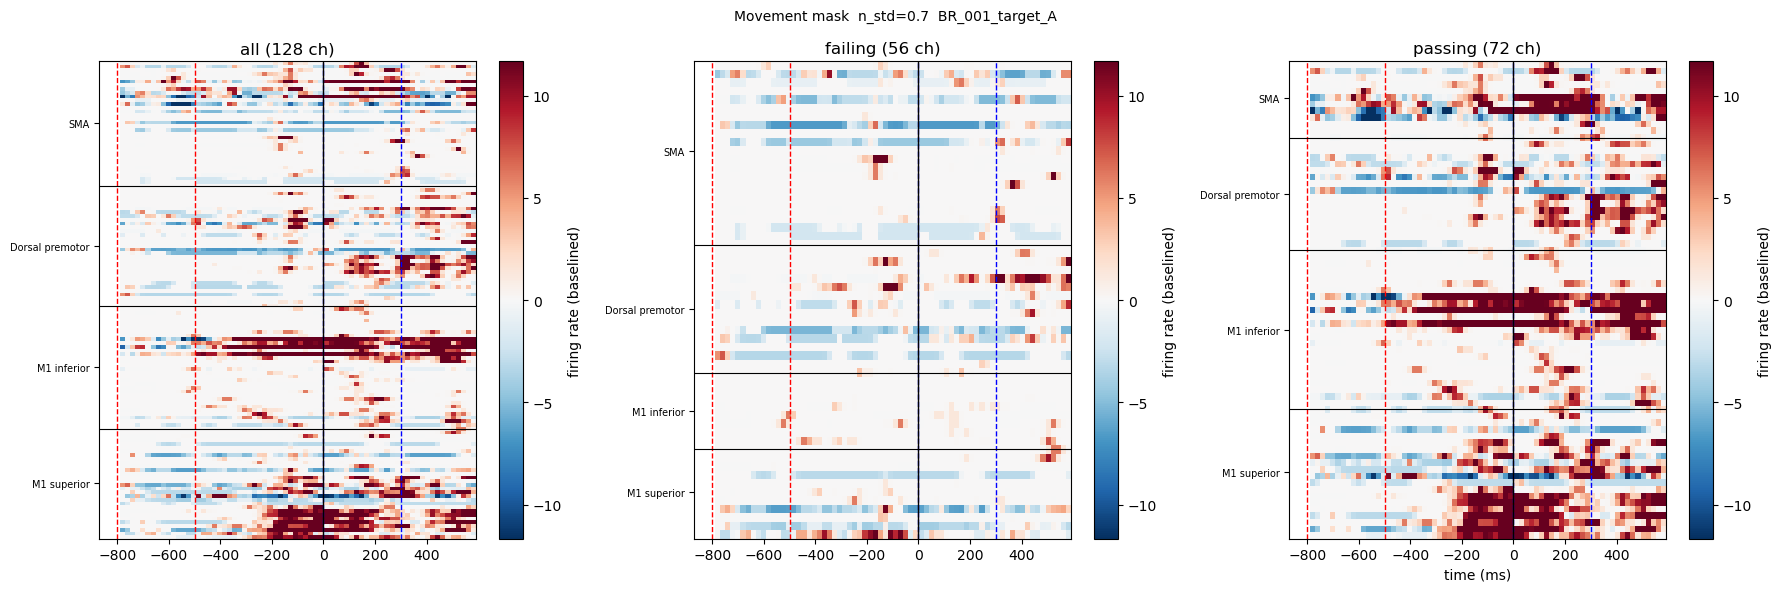

[chan-sel][move] 72/128 channels pass movement criterion
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond=15 | n_trials=4 | path=peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
  STIM     | target=target_A | cond=16 | n_trials=11 | path=peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
  STIM     | target=target_A | cond=17 | n_trials=5 | path=peristim__NRR_RW022_260311_143434__BR_017_target_A.npz
[rsa-ch] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/

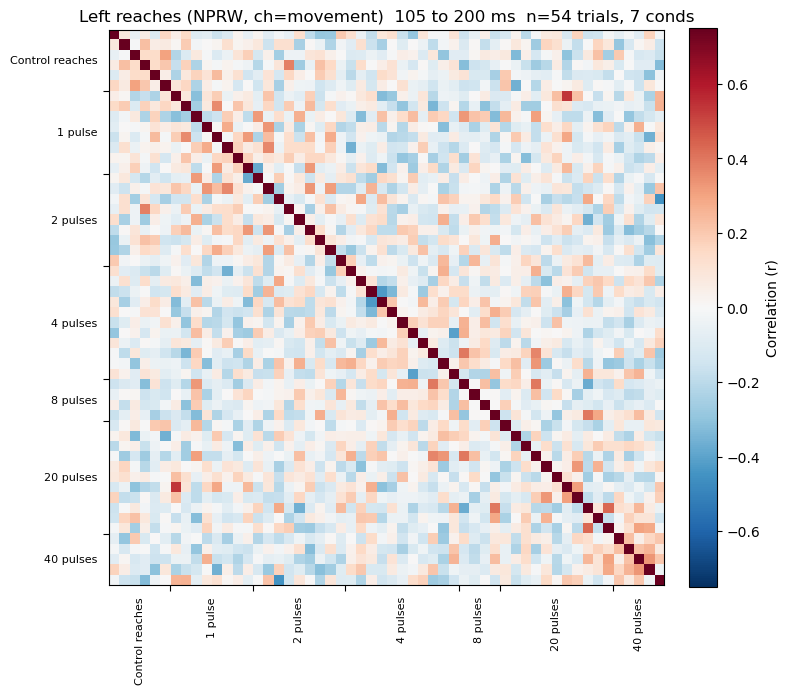

[rsa-ch] done: 54 total trials
[rsa-ch] source='NPRW'  criterion='stim'  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
[chan-sel][stim] ctrl pool: 18 time×trial samples
[chan-sel][stim] 64/128 pass for peristim__NRR_RW022_260311_142040__BR_011_target_A.npz


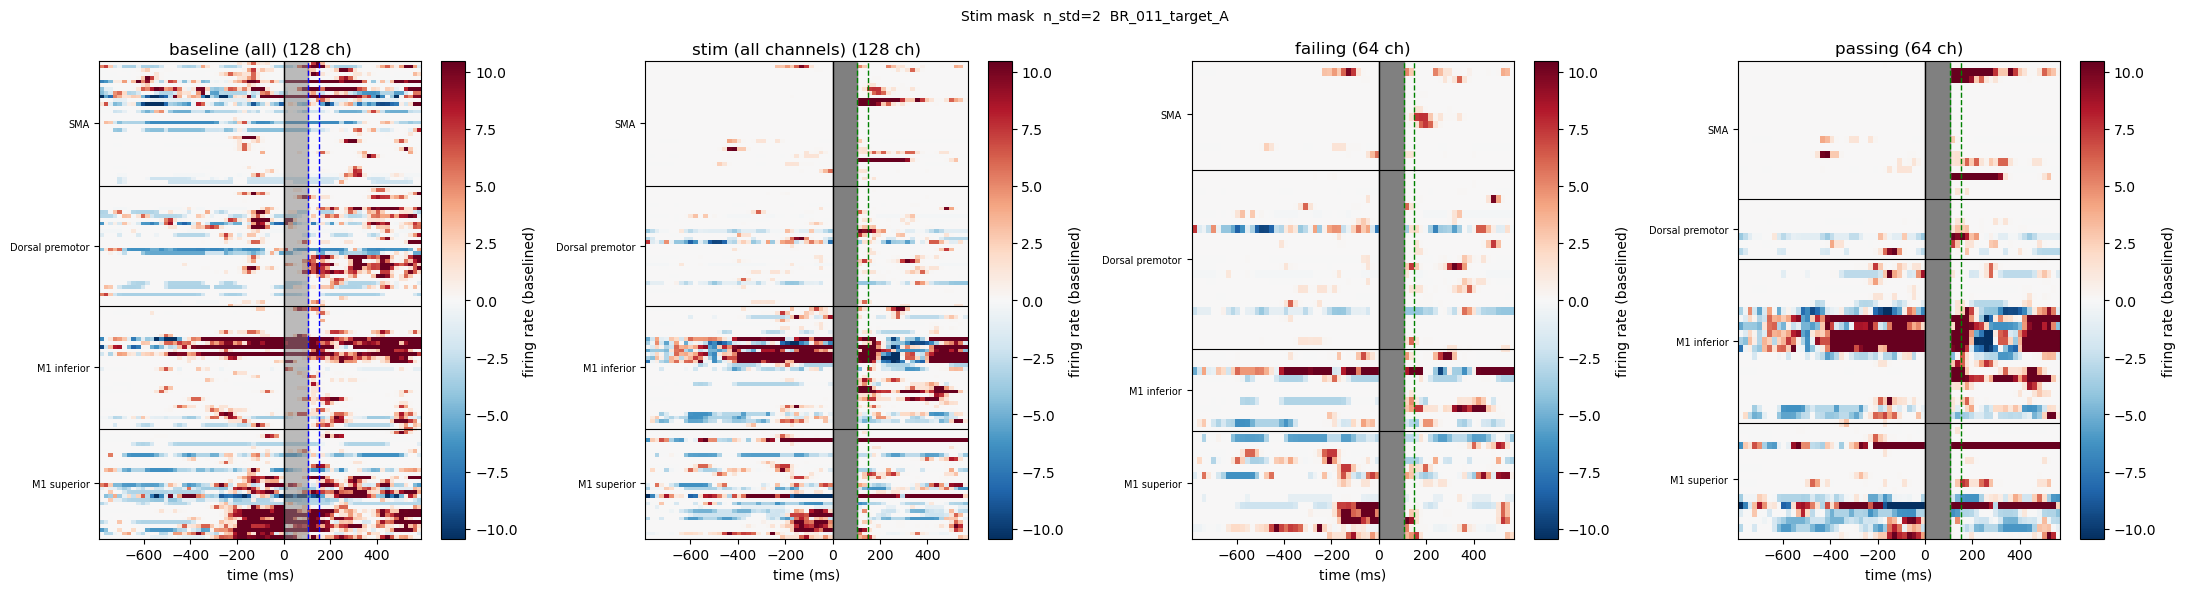

[chan-sel][stim] 74/128 pass for peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
[chan-sel][stim] 87/128 pass for peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
[chan-sel][stim] 44/128 pass for peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
[chan-sel][stim] 78/128 pass for peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
[chan-sel][stim] 76/128 pass for peristim__NRR_RW022_260311_143434__BR_017_target_A.npz
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond

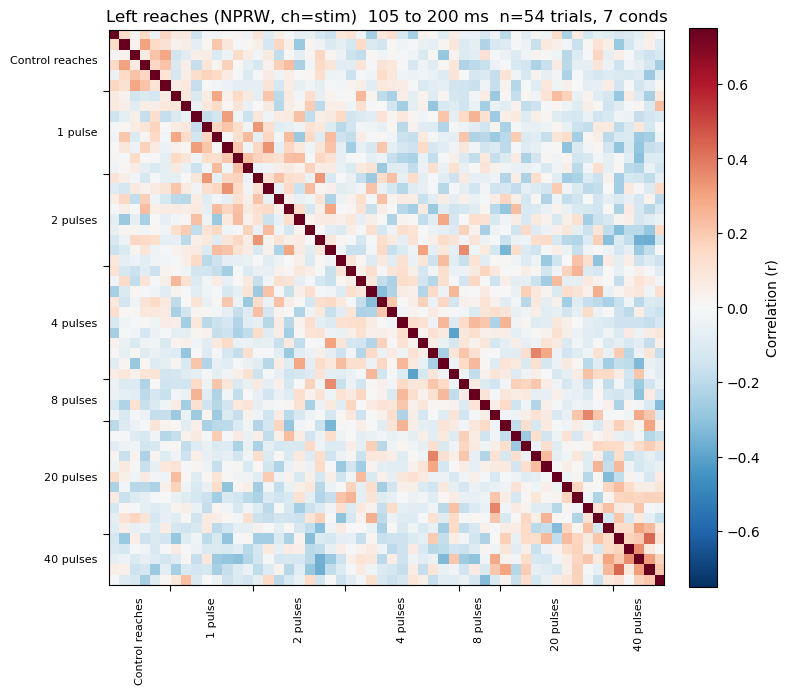

[rsa-ch] done: 54 total trials
[rsa-ch] source='NPRW'  criterion='union'  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz


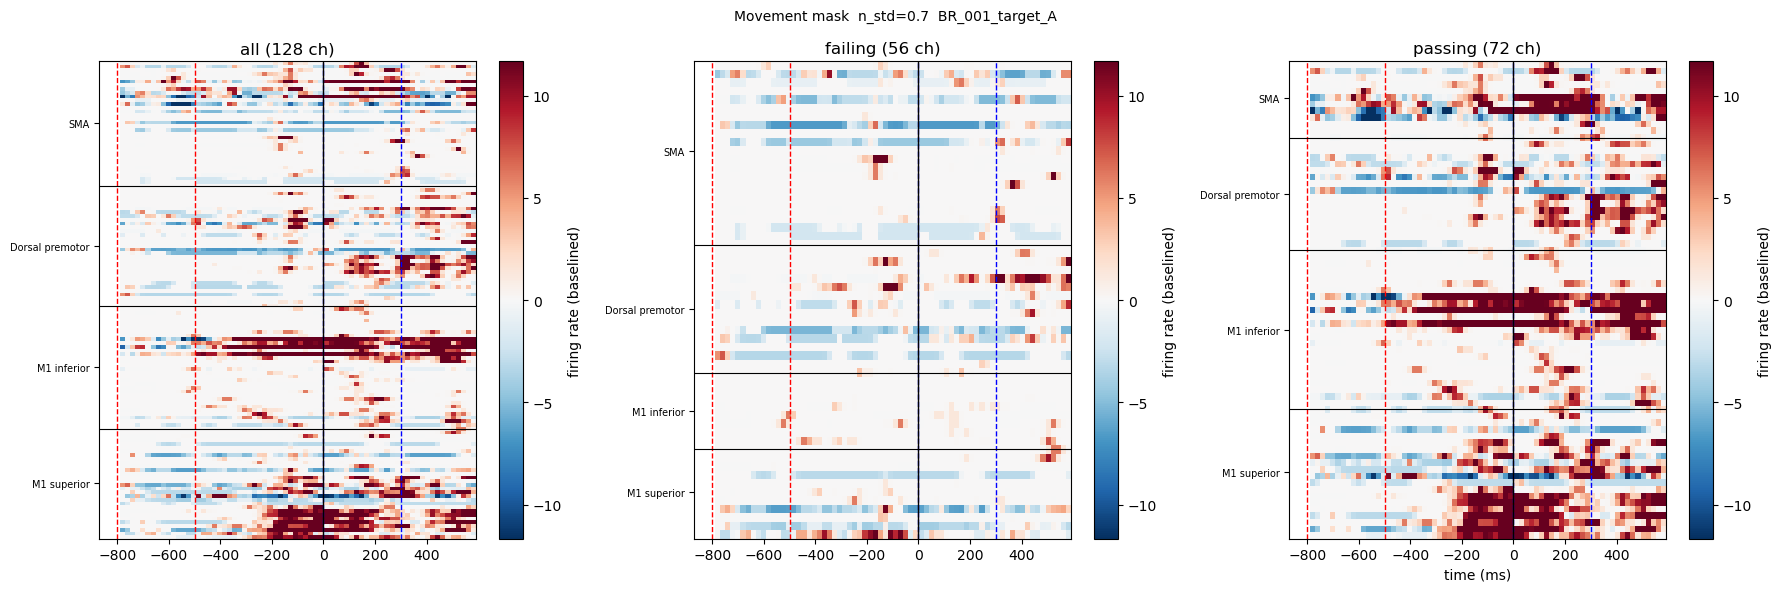

[chan-sel][move] 72/128 channels pass movement criterion
[chan-sel][stim] ctrl pool: 18 time×trial samples
[chan-sel][stim] 64/128 pass for peristim__NRR_RW022_260311_142040__BR_011_target_A.npz


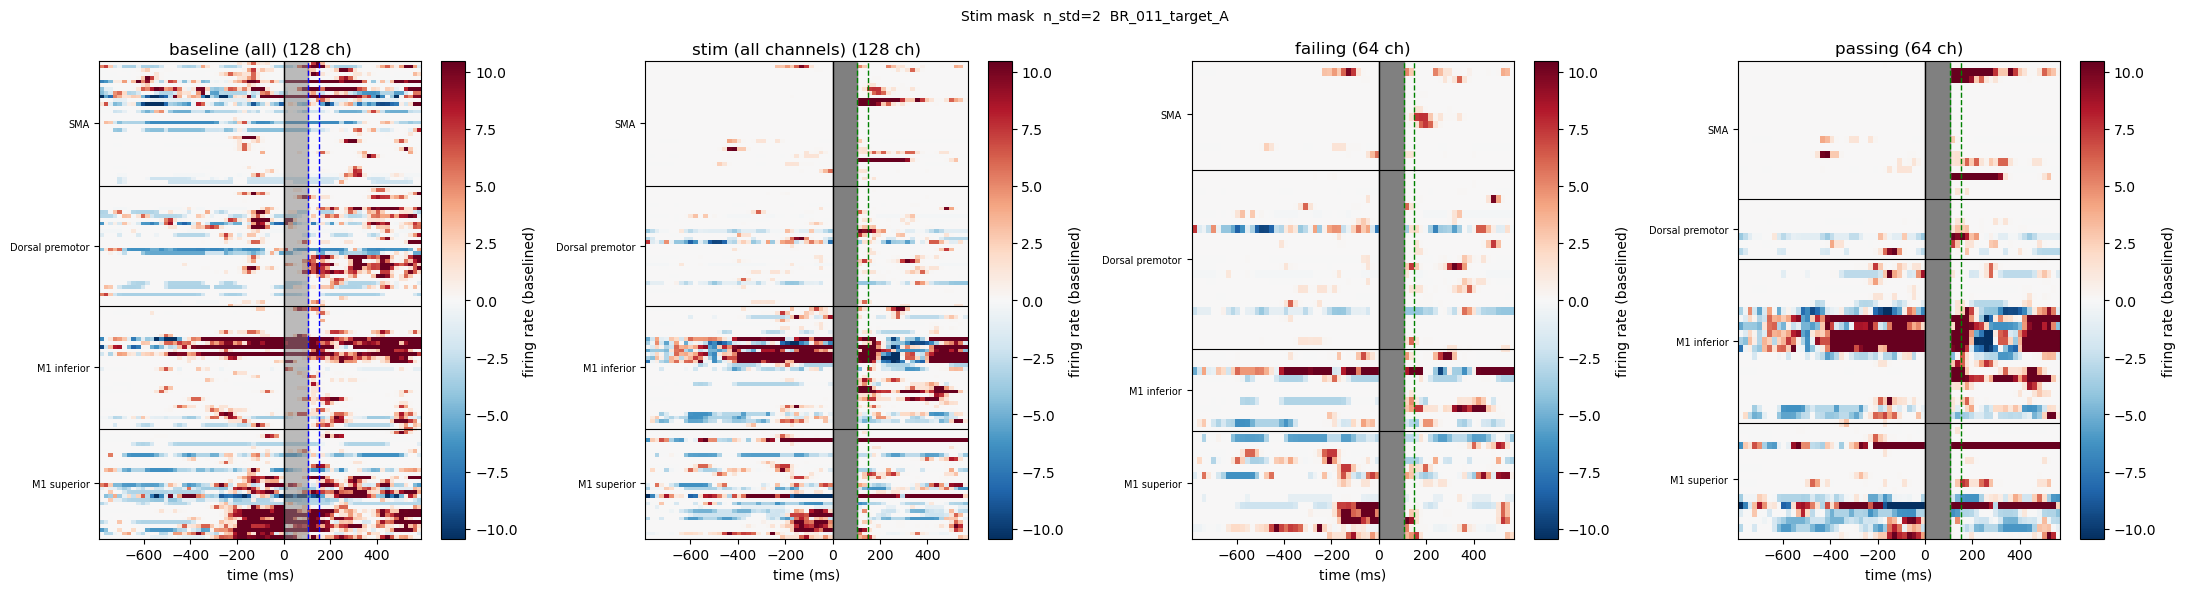

[chan-sel][stim] 74/128 pass for peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
[chan-sel][stim] 87/128 pass for peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
[chan-sel][stim] 44/128 pass for peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
[chan-sel][stim] 78/128 pass for peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
[chan-sel][stim] 76/128 pass for peristim__NRR_RW022_260311_143434__BR_017_target_A.npz
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond

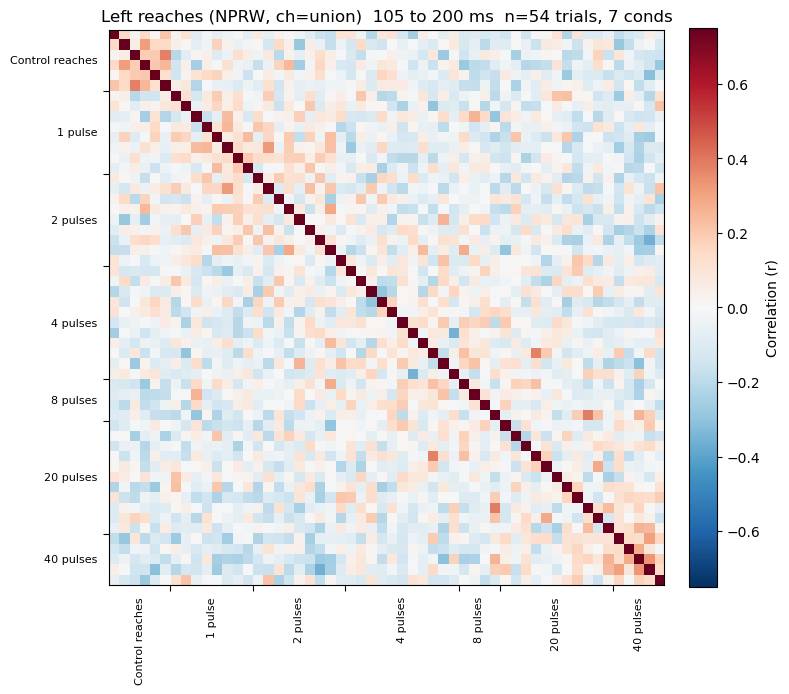

[rsa-ch] done: 54 total trials
[rsa-ch] source='NPRW'  criterion='intersection'  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond=15 | n_trials=4 | path=peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
  STIM     | target=target_A | cond=16 | n_trials=11 | path=peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
  STIM     | target=target

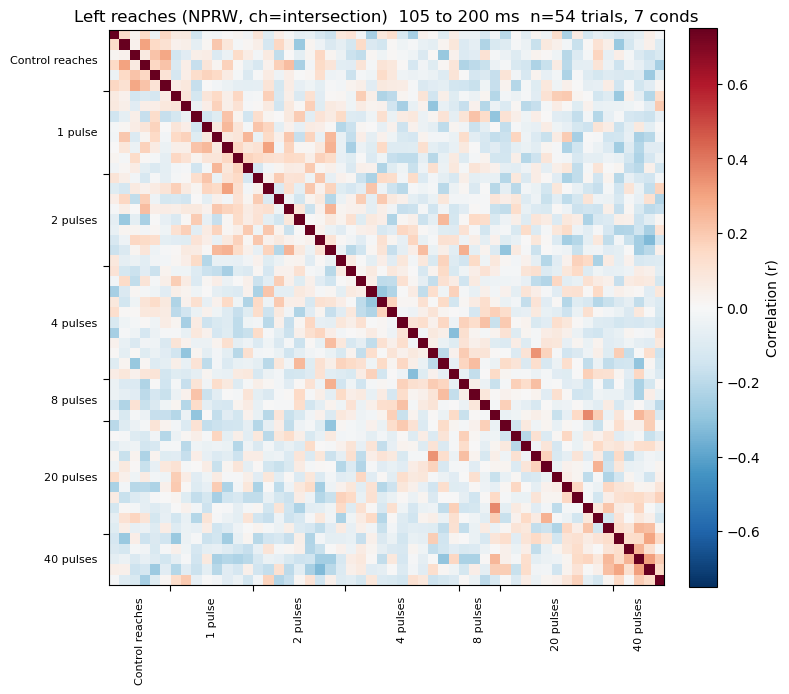

[rsa-ch] done: 54 total trials
[rsa-ch] source='NPRW'  criterion=None  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond=15 | n_trials=4 | path=peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
  STIM     | target=target_A | cond=16 | n_trials=11 | path=peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
  STIM     | target=target_A | cond=

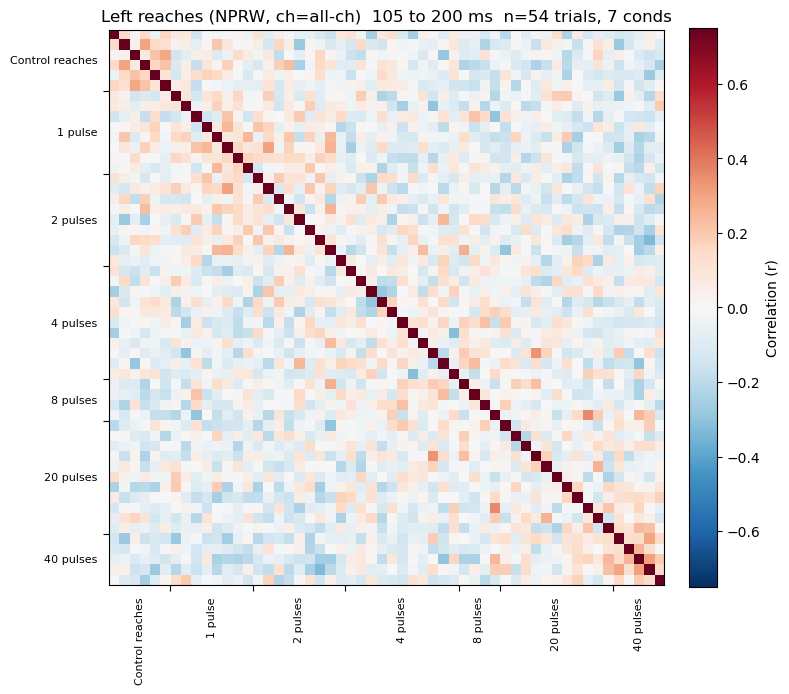

[rsa-ch] done: 54 total trials


In [8]:
for _crit in ("movement", "stim", "union", "intersection", None):
    run_trial_rsa_channel_criterion(
        source="NPRW",
        corr_win_ms=(105.0, 200.0),
        channel_criterion=_crit,
        cond_label_extras=cond_label_extras,
        vmin=-0.75, vmax=0.75,
        baseline_port="A",
        skip_conds={2, 3, 4, 5, 6, 7, 8, 9, 10, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31},
        cond_order=["Baseline", 11, 12, 14, 15, 16, 17],
    )

[rsa-ch] source='UA'  criterion='movement'  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz


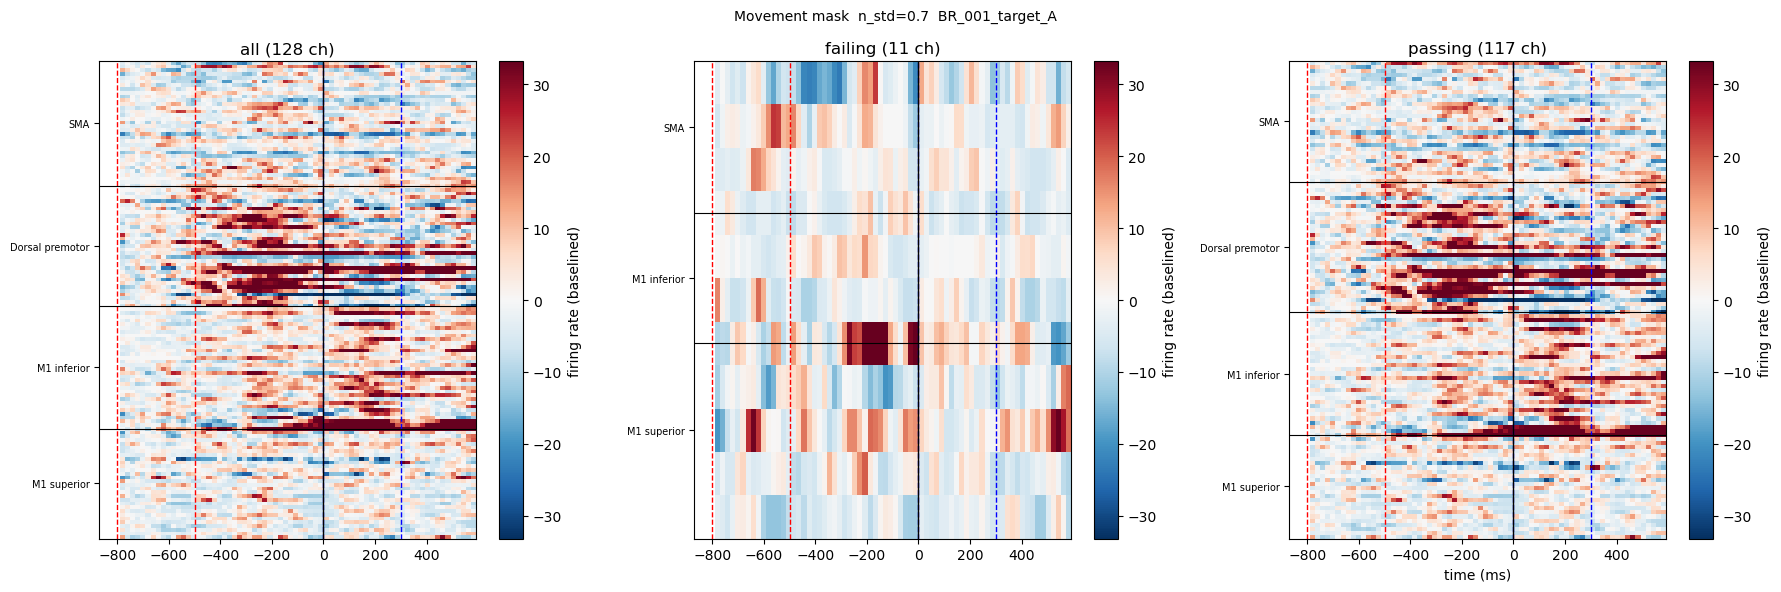

[chan-sel][move] 117/128 channels pass movement criterion
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond=15 | n_trials=4 | path=peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
  STIM     | target=target_A | cond=16 | n_trials=11 | path=peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
  STIM     | target=target_A | cond=17 | n_trials=5 | path=peristim__NRR_RW022_260311_143434__BR_017_target_A.npz
[rsa-ch] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP

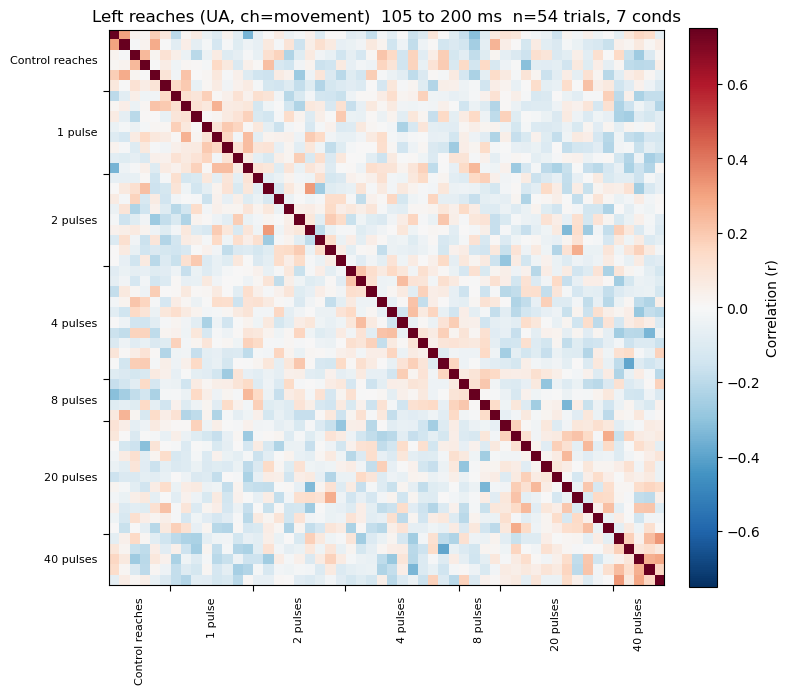

[rsa-ch] done: 54 total trials
[rsa-ch] source='UA'  criterion='stim'  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
[chan-sel][stim] ctrl pool: 18 time×trial samples
[chan-sel][stim] 74/128 pass for peristim__NRR_RW022_260311_142040__BR_011_target_A.npz


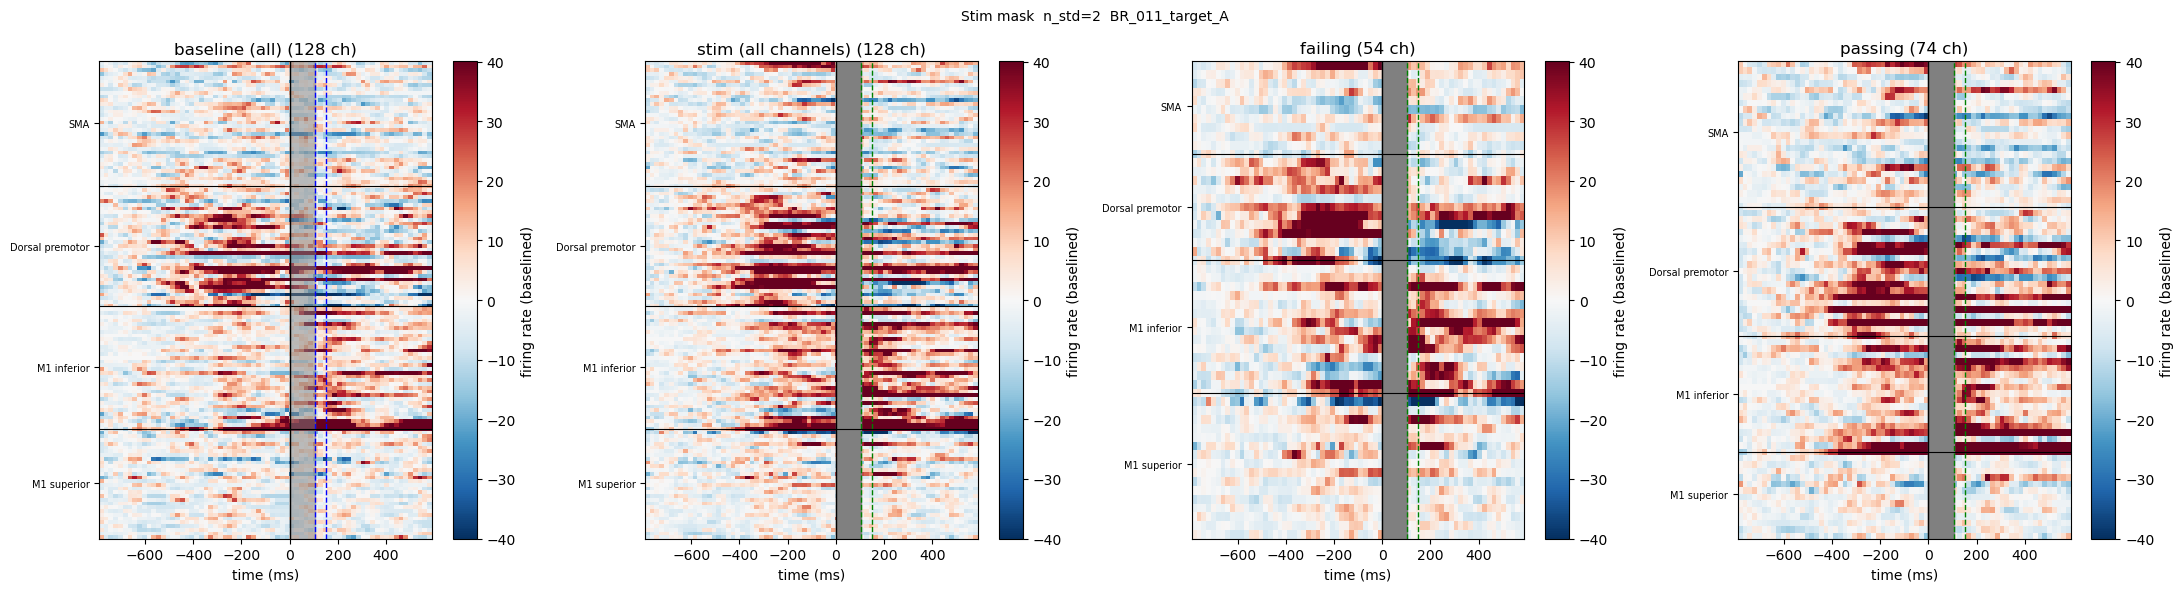

[chan-sel][stim] 79/128 pass for peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
[chan-sel][stim] 73/128 pass for peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
[chan-sel][stim] 47/128 pass for peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
[chan-sel][stim] 76/128 pass for peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
[chan-sel][stim] 98/128 pass for peristim__NRR_RW022_260311_143434__BR_017_target_A.npz
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond

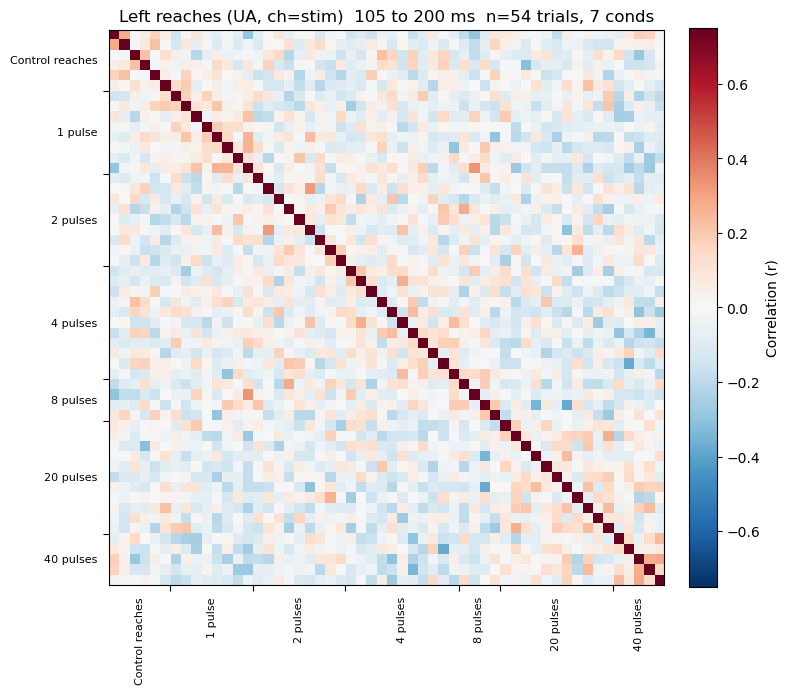

[rsa-ch] done: 54 total trials
[rsa-ch] source='UA'  criterion='union'  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz


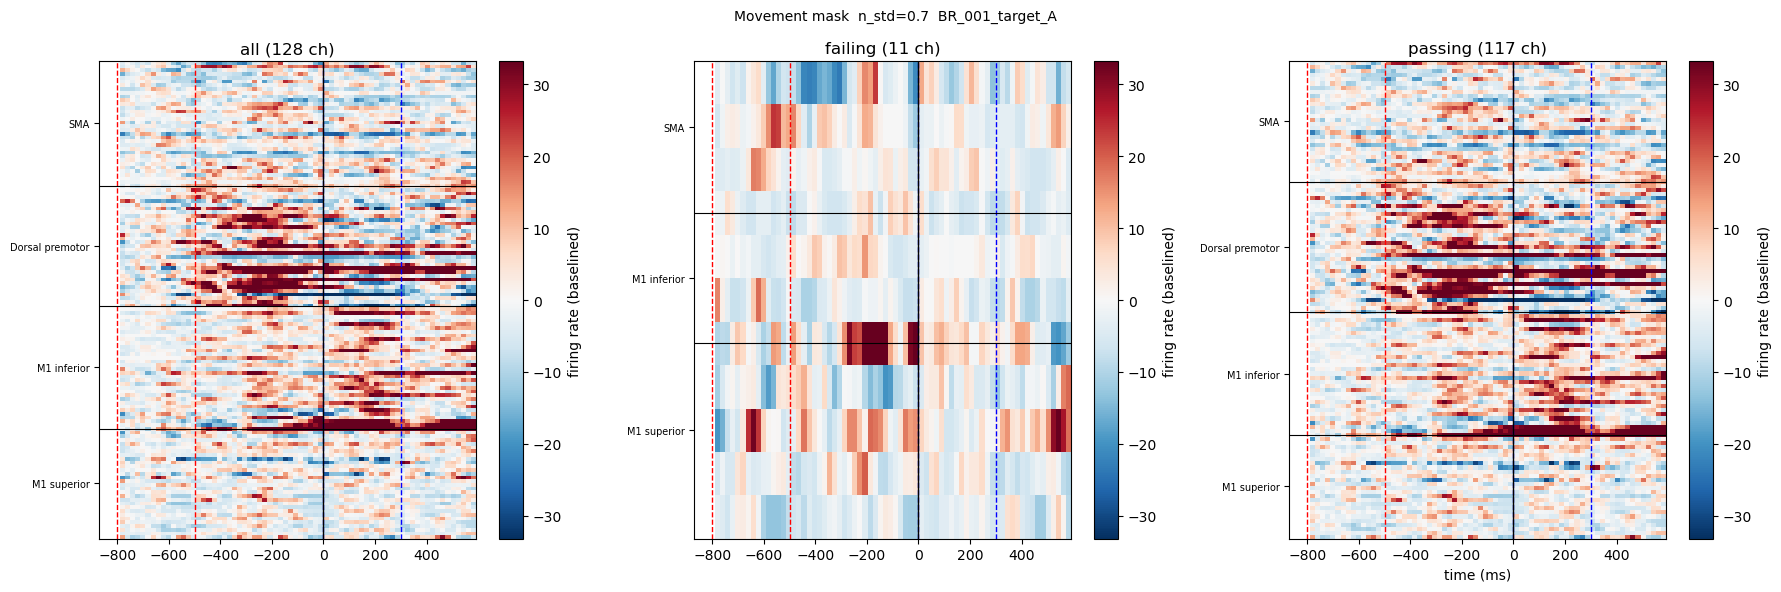

[chan-sel][move] 117/128 channels pass movement criterion
[chan-sel][stim] ctrl pool: 18 time×trial samples
[chan-sel][stim] 74/128 pass for peristim__NRR_RW022_260311_142040__BR_011_target_A.npz


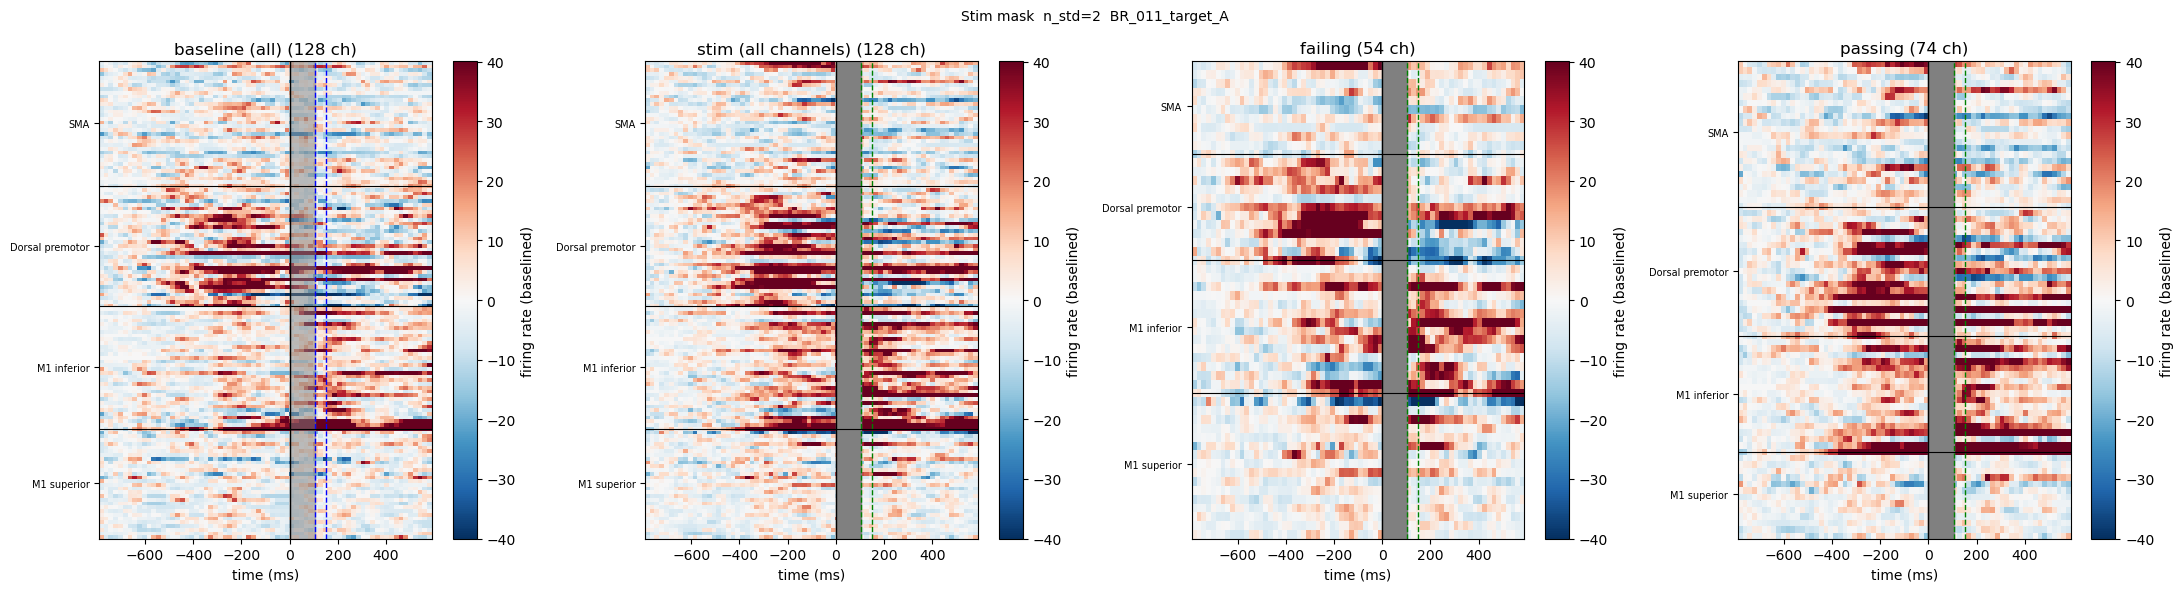

[chan-sel][stim] 79/128 pass for peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
[chan-sel][stim] 73/128 pass for peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
[chan-sel][stim] 47/128 pass for peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
[chan-sel][stim] 76/128 pass for peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
[chan-sel][stim] 98/128 pass for peristim__NRR_RW022_260311_143434__BR_017_target_A.npz
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond

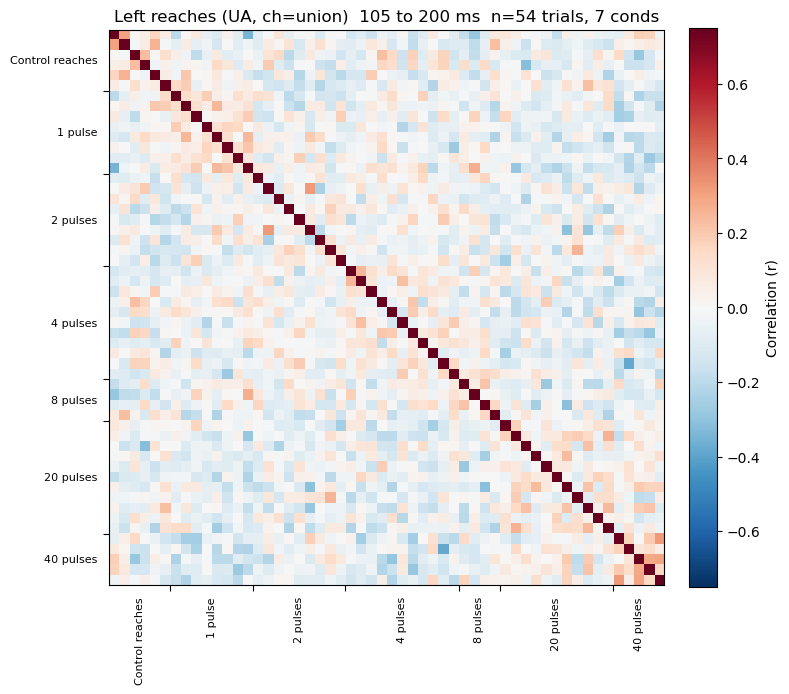

[rsa-ch] done: 54 total trials
[rsa-ch] source='UA'  criterion='intersection'  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond=15 | n_trials=4 | path=peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
  STIM     | target=target_A | cond=16 | n_trials=11 | path=peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
  STIM     | target=target_A

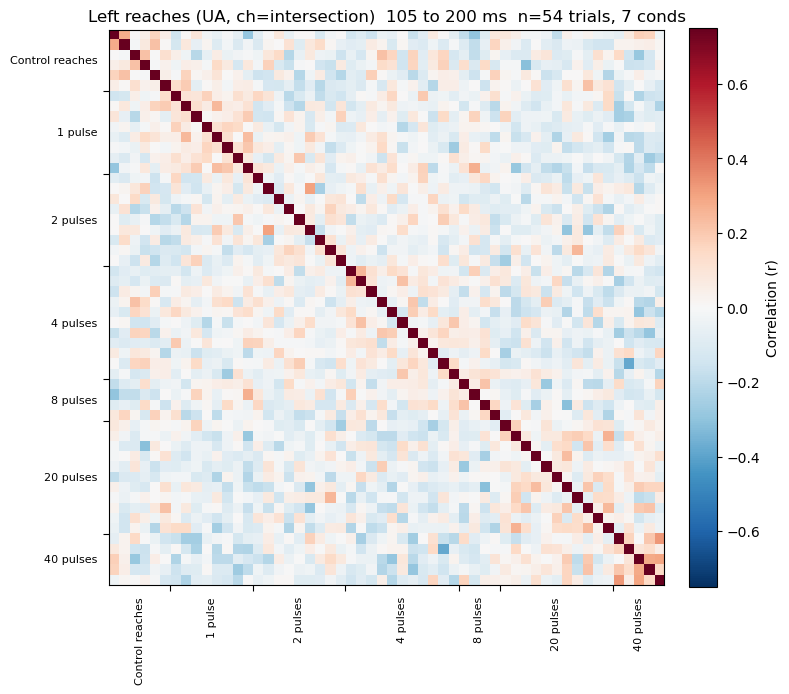

[rsa-ch] done: 54 total trials
[rsa-ch] source='UA'  criterion=None  win=(105.0, 200.0)
[rsa-ch][warn] no file matching BR_002 in control_reaches; using peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
[rsa-ch][skip] skip_conds=19,20,21,22,23,24,25,27,28,29,30,31
  BASELINE | target=target_A | cond=Baseline | n_trials=6 | path=peristim__NRR_RW022_260311_135426__BR_001_target_A.npz
  STIM     | target=target_A | cond=11 | n_trials=8 | path=peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
  STIM     | target=target_A | cond=12 | n_trials=9 | path=peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
  STIM     | target=target_A | cond=14 | n_trials=11 | path=peristim__NRR_RW022_260311_142914__BR_014_target_A.npz
  STIM     | target=target_A | cond=15 | n_trials=4 | path=peristim__NRR_RW022_260311_143050__BR_015_target_A.npz
  STIM     | target=target_A | cond=16 | n_trials=11 | path=peristim__NRR_RW022_260311_143246__BR_016_target_A.npz
  STIM     | target=target_A | cond=17

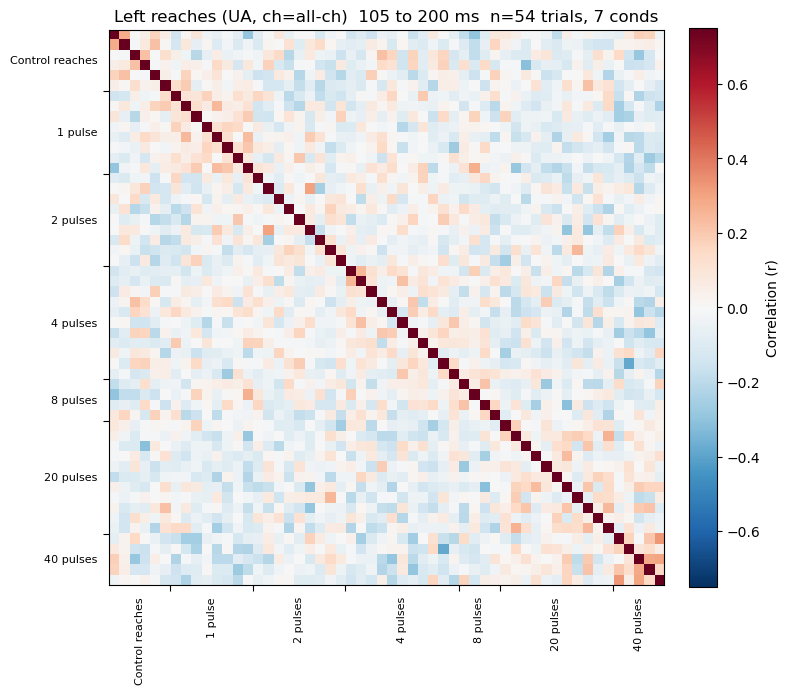

[rsa-ch] done: 54 total trials


In [ ]:
for _crit in ("movement", "stim", "union", "intersection", None):
    run_trial_rsa_channel_criterion(
        source="UA",
        corr_win_ms=(105.0, 200.0),
        channel_criterion=_crit,
        cond_label_extras=cond_label_extras,
        vmin=-0.75, vmax=0.75,
        baseline_port="A",
        skip_conds={2, 3, 4, 5, 6, 7, 8, 9, 10, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31},
        cond_order=["Baseline", 11, 12, 14, 15, 16, 17],
    )